In [1]:
import tensorflow as tf
from tensorflow.keras import models, layers
import matplotlib.pyplot as plt
from tensorflow import keras
from tensorflow.keras.preprocessing import image_dataset_from_directory

In [2]:
from sklearn.datasets import make_circles
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import cohen_kappa_score
from sklearn.metrics import roc_auc_score
from sklearn.metrics import confusion_matrix
from keras.models import Sequential
from keras.layers import Dense

In [3]:
IMAGE_SIZE = 256
BATCH_SIZE = 32
CHANNELS = 3
EPOCHS = 50

In [4]:
dataset = tf.keras.preprocessing.image_dataset_from_directory(
"Disease",
shuffle = True,
image_size = (IMAGE_SIZE,IMAGE_SIZE),
batch_size = BATCH_SIZE
)

Found 684 files belonging to 4 classes.


In [5]:
class_names = dataset.class_names
class_names

['Chickenpox', 'Measles', 'Monkeypox', 'Normal']

(32, 256, 256, 3)
[2 2 3 1 3 3 2 3 3 3 3 1 3 2 2 2 2 3 3 3 3 2 1 3 3 2 2 1 3 2 3 2]


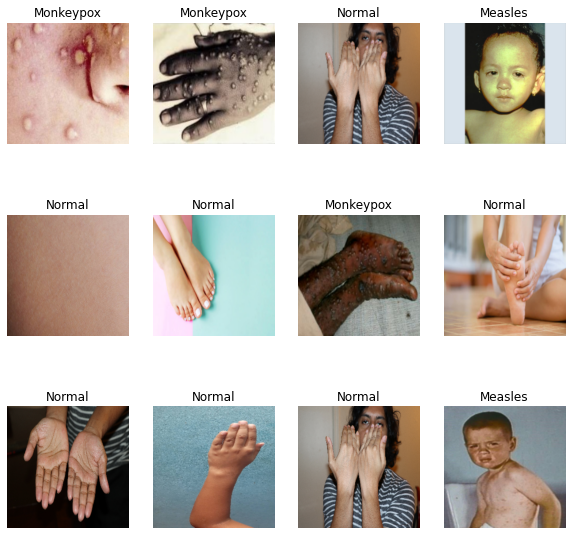

In [6]:
plt.figure(figsize=(10,10))
for image_batch, labels_batch in dataset.take(1):
    print(image_batch.shape)
    print(labels_batch.numpy())
    for i in range(12):
        ax = plt.subplot(3,4,i+1)
        plt.title(class_names[labels_batch[i]])
        plt.imshow(image_batch[i].numpy().astype("uint8"))
        plt.axis("off")

In [7]:
train_size = 0.8
len(dataset)*train_size

17.6

In [8]:
train_ds = dataset.take(16)
len(train_ds)

16

In [9]:
test_ds = dataset.skip(16)
len(test_ds)

6

In [10]:
val_size = 0.1
len(dataset)*val_size

2.2

In [11]:
#80% ==> Training
#20% ==> Test
    #10% ==> Validation
    #10% ==> Test

In [12]:
val_ds = test_ds.take(2)
len(val_ds)

2

In [13]:
test_ds = test_ds.skip(2)
len(test_ds)

4

In [14]:
def get_dataset_partition_tf(ds, train_split=0.8, val_split=0.1, test_split=0.1, shuffle=True, shuffle_size=10000):
    assert(train_split+test_split+val_split)==1
    
    ds_size= len(ds)
    
    if shuffle:
        ds = ds.shuffle(shuffle_size, seed=12)
    
    train_size = int(train_split*ds_size)
    val_size = int(val_split*ds_size)
    train_ds = ds.take(train_size)
    val_ds = ds.skip(train_size).take(val_size)
    test_ds = ds.skip(train_size).skip(val_size)
    
    return train_ds, val_ds, test_ds

In [15]:
train_ds, val_ds, test_ds = get_dataset_partition_tf(dataset)

In [16]:
len(train_ds)

17

In [17]:
len(val_ds)

2

In [18]:
len(test_ds)

3

In [19]:
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
val_ds = val_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
test_ds = test_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)

In [20]:
for image_batch, labels_batch in dataset.take(1):
    print(image_batch[0].numpy()/255)

[[[0.7372549  0.54901963 0.45882353]
  [0.73406863 0.54583335 0.45563725]
  [0.7252451  0.5370098  0.44681373]
  ...
  [0.55710787 0.33088234 0.26691177]
  [0.5497549  0.3262255  0.25955883]
  [0.5529412  0.32941177 0.2627451 ]]

 [[0.7245098  0.5362745  0.44607842]
  [0.72391236 0.5356771  0.445481  ]
  [0.7200674  0.5318321  0.44163603]
  ...
  [0.55810356 0.33406863 0.26790747]
  [0.5535386  0.3300092  0.26334253]
  [0.5593137  0.33578432 0.26911765]]

 [[0.72156864 0.53333336 0.44313726]
  [0.71937805 0.5311428  0.4409467 ]
  [0.71803004 0.52979475 0.43959865]
  ...
  [0.56187195 0.33834252 0.2735294 ]
  [0.5598039  0.3362745  0.26960784]
  [0.5661765  0.34264705 0.27598038]]

 ...

 [[0.7762255  0.59583336 0.49387255]
  [0.7901654  0.6097733  0.5078125 ]
  [0.79725796 0.6168658  0.51490504]
  ...
  [0.63175553 0.4317555  0.34940258]
  [0.6360294  0.4360294  0.35367647]
  [0.6392157  0.4392157  0.35686275]]

 [[0.785049   0.6046569  0.5026961 ]
  [0.79281557 0.6124234  0.51046264]


In [21]:
resize_and_rescale = tf.keras.Sequential([
    layers.experimental.preprocessing.Resizing(IMAGE_SIZE, IMAGE_SIZE),
    layers.experimental.preprocessing.Rescaling(1.0/255)
])

In [22]:
data_augmentation = tf.keras.Sequential([
    layers.experimental.preprocessing.RandomFlip("horizontal_and_vertical"),
    layers.experimental.preprocessing.RandomRotation(0.2)
])

In [23]:
input_shape = (BATCH_SIZE, IMAGE_SIZE, IMAGE_SIZE,CHANNELS)
n_classes = 4

model = models.Sequential([
    resize_and_rescale,
    data_augmentation,
    layers.Conv2D(32,kernel_size=(3,3), activation='relu', input_shape=input_shape),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64,kernel_size=(3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64,kernel_size=(3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Flatten(),
    layers.Dense(64,activation='relu'),
    layers.Dense(n_classes, activation='softmax'),
    
    
    
])

model.build(input_shape = input_shape)

In [24]:
model.summary()

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 sequential (Sequential)     (32, 256, 256, 3)         0         
                                                                 
 sequential_1 (Sequential)   (None, 256, 256, 3)       0         
                                                                 
 conv2d (Conv2D)             (None, 254, 254, 32)      896       
                                                                 
 max_pooling2d (MaxPooling2D  (None, 127, 127, 32)     0         
 )                                                               
                                                                 
 conv2d_1 (Conv2D)           (None, 125, 125, 64)      18496     
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 62, 62, 64)       0         
 2D)                                                  

In [25]:
X = train_ds
y= test_ds

In [26]:
model.compile(
   optimizer='adam', 
   loss = tf.keras.losses.SparseCategoricalCrossentropy(from_logits= False),
   metrics=['accuracy']
)

In [27]:
history = model.fit(
    train_ds,
    batch_size=BATCH_SIZE,
    validation_data=val_ds,
    verbose=1,
    epochs=EPOCHS
)

Epoch 1/50
17/17 [==============================] - 28s 1s/step - loss: 1.1405 - accuracy: 0.3950 - val_loss: 0.9498 - val_accuracy: 0.5000
Epoch 2/50
17/17 [==============================] - 19s 1s/step - loss: 0.9973 - accuracy: 0.4618 - val_loss: 0.9645 - val_accuracy: 0.5000
Epoch 3/50
17/17 [==============================] - 21s 1s/step - loss: 0.9731 - accuracy: 0.5057 - val_loss: 0.8988 - val_accuracy: 0.5000
Epoch 4/50
17/17 [==============================] - 21s 1s/step - loss: 0.9391 - accuracy: 0.5382 - val_loss: 0.8334 - val_accuracy: 0.6094
Epoch 5/50
17/17 [==============================] - 22s 1s/step - loss: 0.9215 - accuracy: 0.5687 - val_loss: 0.9176 - val_accuracy: 0.5938
Epoch 6/50
17/17 [==============================] - 23s 1s/step - loss: 0.8479 - accuracy: 0.6508 - val_loss: 0.7656 - val_accuracy: 0.6406
Epoch 7/50
17/17 [==============================] - 22s 1s/step - loss: 0.7834 - accuracy: 0.6794 - val_loss: 0.6980 - val_accuracy: 0.7656
Epoch 8/50
17/17 [==

17/17 [==============================] - 23s 1s/step - loss: 0.3920 - accuracy: 0.8435 - val_loss: 0.4514 - val_accuracy: 0.8281
Epoch 50/50
17/17 [==============================] - 23s 1s/step - loss: 0.3764 - accuracy: 0.8645 - val_loss: 0.5119 - val_accuracy: 0.8125


In [28]:
scores = model.evaluate(test_ds)

3/3 [==============================] - 2s 241ms/step - loss: 0.5925 - accuracy: 0.7708


In [29]:
history.history['accuracy']

[0.3950381577014923,
 0.46183204650878906,
 0.5057252049446106,
 0.5381679534912109,
 0.5687022805213928,
 0.6507633328437805,
 0.6793892979621887,
 0.6469465494155884,
 0.6851145029067993,
 0.6679389476776123,
 0.7175572514533997,
 0.7137404680252075,
 0.6965649127960205,
 0.7519084215164185,
 0.7194656729698181,
 0.732824444770813,
 0.75,
 0.7538167834281921,
 0.7270992398262024,
 0.7767175436019897,
 0.7690839767456055,
 0.7633587718009949,
 0.767175555229187,
 0.7748091816902161,
 0.7729007601737976,
 0.7977099418640137,
 0.7709923386573792,
 0.7843511700630188,
 0.8091602921485901,
 0.7843511700630188,
 0.8015267252922058,
 0.8091602921485901,
 0.7996183037757874,
 0.805343508720398,
 0.8206107020378113,
 0.8206107020378113,
 0.7843511700630188,
 0.8206107020378113,
 0.8072519302368164,
 0.8416030406951904,
 0.830152690410614,
 0.8396946787834167,
 0.8454198241233826,
 0.8435114622116089,
 0.8492366671562195,
 0.8492366671562195,
 0.8358778357505798,
 0.8549618124961853,
 0.843511

In [30]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

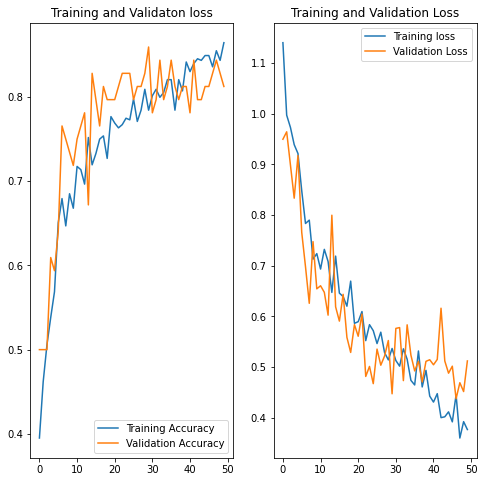

In [31]:
plt.figure(figsize=(8,8))
plt.subplot(1,2,1)
plt.plot(range(EPOCHS), acc, label='Training Accuracy')
plt.plot(range(EPOCHS), val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validaton loss')

plt.subplot(1,2,2)
plt.plot(range(EPOCHS), loss,label='Training loss')
plt.plot(range(EPOCHS), val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()


First image to predict
Label: Normal
1/1 [==============================] - 1s 660ms/step
Predicted Label: Normal


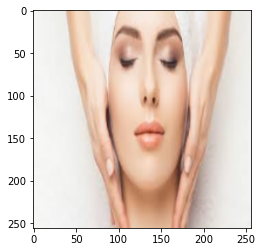

In [32]:
import numpy as np
for images_batch, labels_batch in test_ds.take(1):
    
    first_image = images_batch[0].numpy().astype("uint8")
    
    print("First image to predict")
    plt.imshow(first_image)
    print("Label:", class_names[labels_batch[0].numpy()])
    
    batch_prediction = model.predict(images_batch)
    print("Predicted Label:",class_names[np.argmax(batch_prediction[0])])

In [33]:
model_version = 1
model.save(f"../Models/{model_version}")

INFO:tensorflow:Assets written to: ../Models/1\assets


INFO:tensorflow:Assets written to: ../Models/1\assets


In [153]:
!git status

On branch main
Your branch is up to date with 'origin/main'.

Changes not staged for commit:
  (use "git add <file>..." to update what will be committed)
  (use "git restore <file>..." to discard changes in working directory)
	modified:   disease.ipynb

no changes added to commit (use "git add" and/or "git commit -a")


In [147]:
!git init
!git add .
!git commit -m "Initial clean commit"

Initialized empty Git repository in C:/Users/DELL/Desktop/skin/.git/


[master (root-commit) 7bc812e] Initial clean commit
 836 files changed, 2315 insertions(+)
 create mode 100644 .ipynb_checkpoints/disease-checkpoint.ipynb
 create mode 100644 Disease/Chickenpox/1.jfif
 create mode 100644 Disease/Chickenpox/10.jfif
 create mode 100644 Disease/Chickenpox/11.jfif
 create mode 100644 Disease/Chickenpox/12.jfif
 create mode 100644 Disease/Chickenpox/13.jfif
 create mode 100644 Disease/Chickenpox/14.jfif
 create mode 100644 Disease/Chickenpox/15.jfif
 create mode 100644 Disease/Chickenpox/16.jfif
 create mode 100644 Disease/Chickenpox/17.jfif
 create mode 100644 Disease/Chickenpox/18.jfif
 create mode 100644 Disease/Chickenpox/19.jfif
 create mode 100644 Disease/Chickenpox/2.jfif
 create mode 100644 Disease/Chickenpox/20.jfif
 create mode 100644 Disease/Chickenpox/21.jfif
 create mode 100644 Disease/Chickenpox/22.jfif
 create mode 100644 Disease/Chickenpox/23.jfif
 create mode 100644 Disease/Chickenpox/24.jfif
 create mode 100644 Disease/Chickenpox/25.jfif
 

In [148]:
!git branch -M main
!git remote add origin https://github.com/Sakhawat-Saim/disease-ditection.git
!git push -u origin main

branch 'main' set up to track 'origin/main'.


To https://github.com/Sakhawat-Saim/disease-ditection.git
 * [new branch]      main -> main
